<a href="https://colab.research.google.com/github/ChengxuanOuyang/ChengxuanOuyang/blob/main/ATLAS_Cut_Based.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset successfully loaded. Total initial events: 77176

Parameter Analysis: mBB  |  Applied Cut: mBB > 100 and mBB < 150


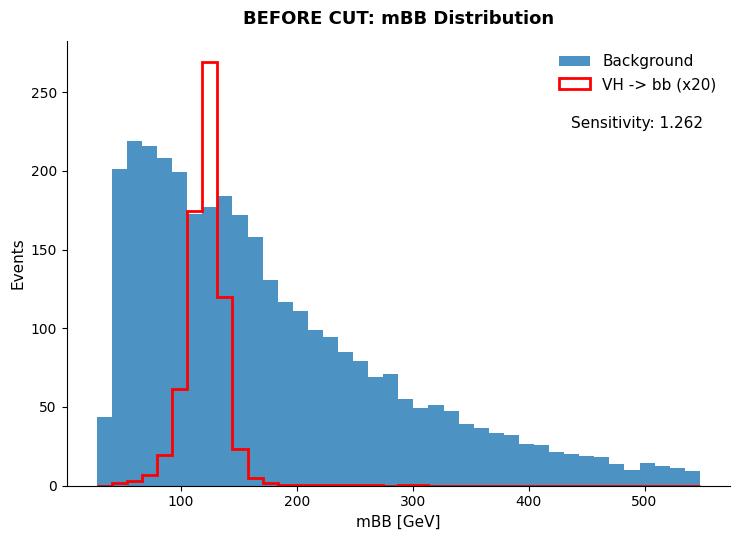

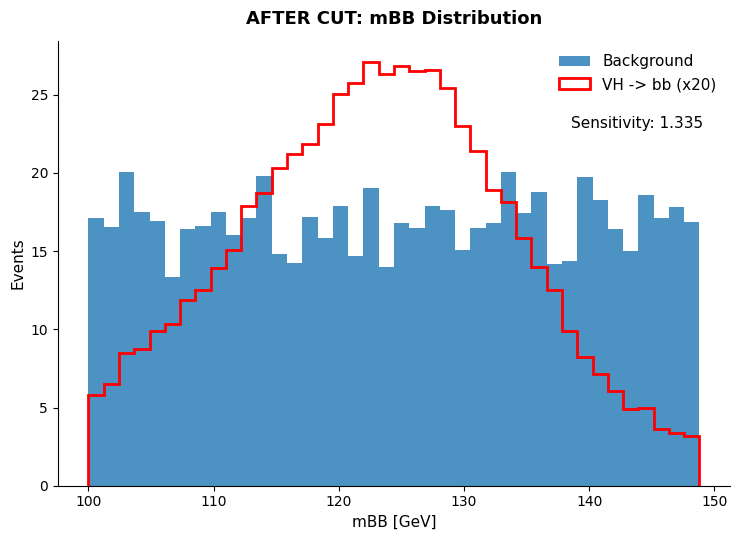


Parameter Analysis: dRBB  |  Applied Cut: dRBB > 0 and dRBB < 2.0


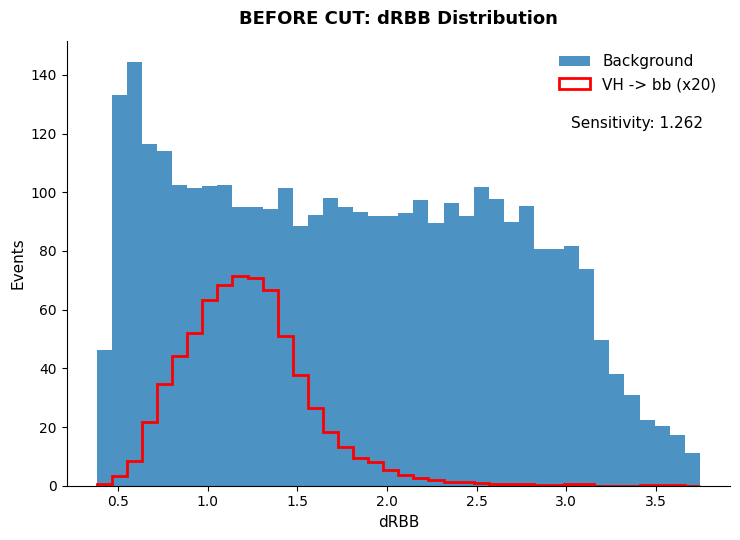

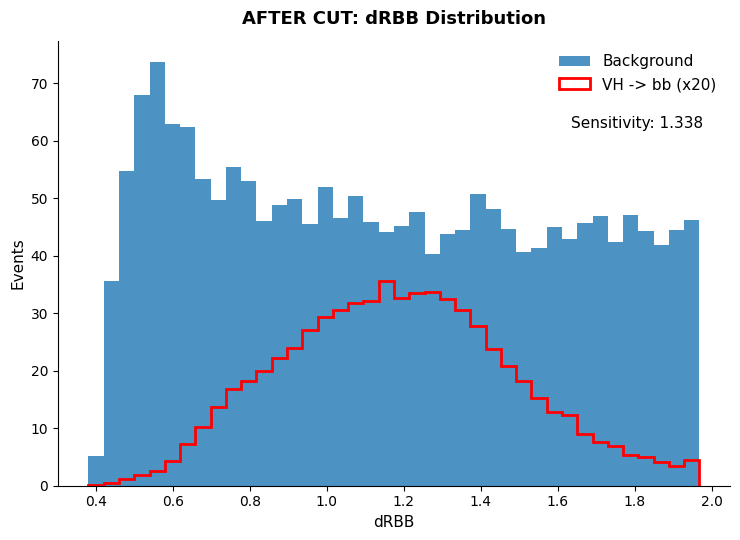


Parameter Analysis: pTV  |  Applied Cut: pTV > 150


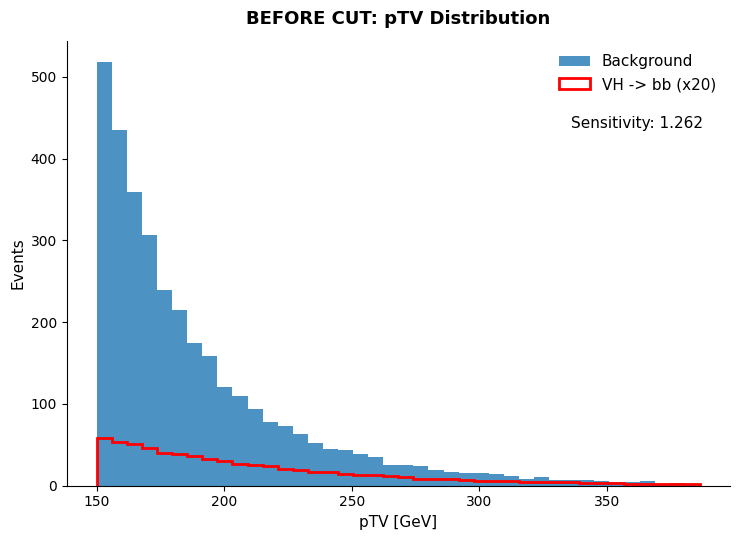

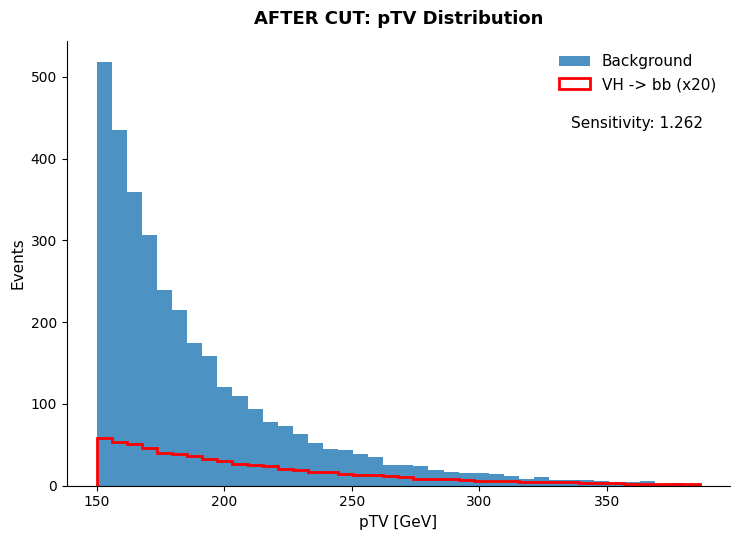


Parameter Analysis: MET  |  Applied Cut: MET > 30


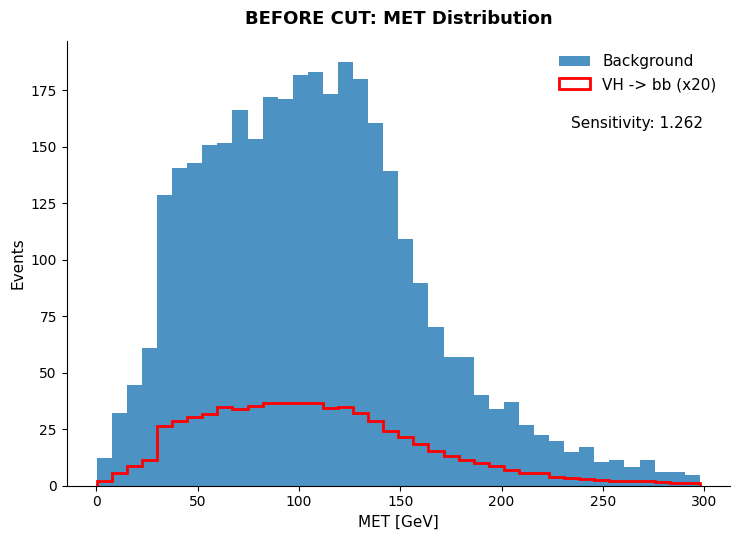

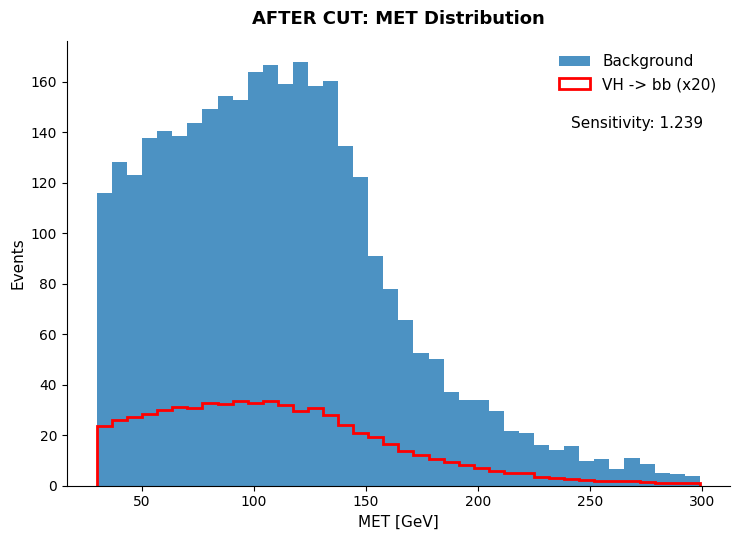


Parameter Analysis: Mtop  |  Applied Cut: Mtop > 0 and (Mtop < 150 or Mtop > 200)


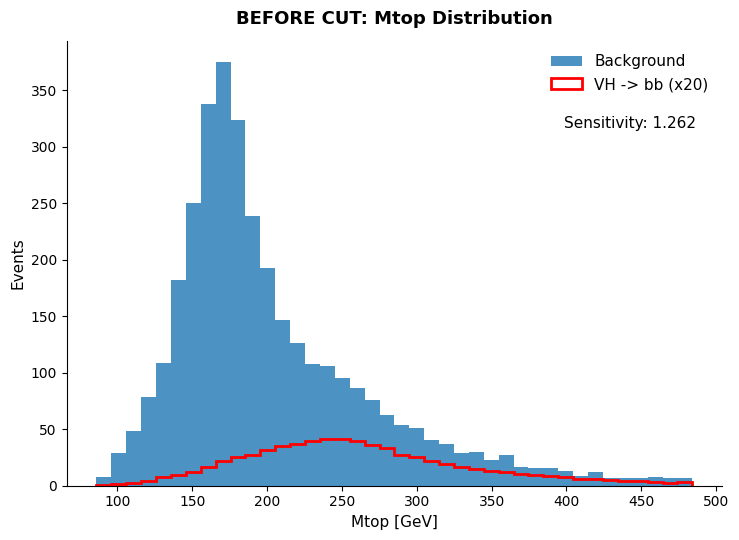

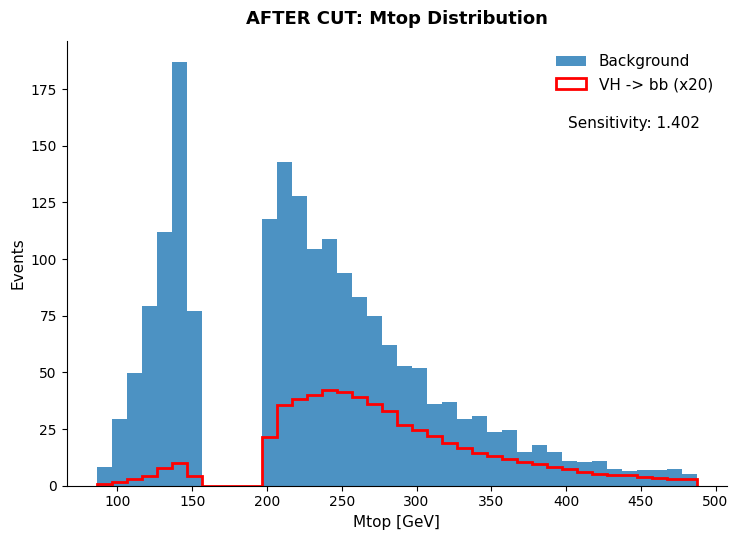



SUMMARY TABLE: CUT-BASED SENSITIVITY EVALUATION
References:
[1] ATLAS Collab., Phys. Lett. B 786 (2018) 59-86. (mBB and pTV cuts)
[2] ATLAS Collab., JHEP 01 (2015) 069. (MET and Mtop cuts)
[3] J. M. Butterworth et al., Phys. Rev. Lett. 100 (2008) 242001. (dRBB cut)
Parameter Cut Applied                             Sens. Before Sens. After Improvement (%)
 mBB                      mBB > 100 and mBB < 150 1.262        1.335        5.79%         
dRBB                      dRBB > 0 and dRBB < 2.0 1.262        1.338        6.02%         
 pTV                                    pTV > 150 1.262        1.262        0.00%         
 MET                                     MET > 30 1.262        1.239       -1.80%         
Mtop      Mtop > 0 and (Mtop < 150 or Mtop > 200) 1.262        1.402       11.14%         



In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def load_and_preprocess_data(filepath: str) -> pd.DataFrame:
    """
    Loads the ATLAS dataset, converts energy variables from MeV to GeV for standard IEEE reporting.
    """
    try:
        df = pd.read_csv(filepath)
        print(f"Dataset successfully loaded. Total initial events: {len(df)}")
    except FileNotFoundError:
        print(f"Error: Dataset not found at {filepath}.")
        raise

    # Convert MeV to GeV for academic standard plots (100,000 MeV -> 100 GeV)
    mev_columns = ['mBB', 'pTV', 'MET', 'Mtop', 'pTB1', 'pTB2', 'pTJ3', 'mBBJ', 'mTW']
    for col in mev_columns:
        if col in df.columns:
            df[col] = df[col] / 1000.0

    return df

def calculate_dynamic_sensitivity(df: pd.DataFrame, weight_col: str, bins: int = 30) -> float:
    """
    Calculates the signal sensitivity using DYNAMIC bin edges.
    This exactly replicates the ATLAS official sensitivity_cut_based() logic.
    """
    is_sig = (df['Class'] == 1) | (df['Class'] == 1.0) | (df['Class'] == 's') | (df['Class'] == '1')
    df_sig = df[is_sig]
    df_bkg = df[~is_sig]

    current_min, current_max = df['mBB'].min(), df['mBB'].max()

    s_hist, edges = np.histogram(df_sig['mBB'], bins=bins, range=(current_min, current_max), weights=df_sig[weight_col])
    b_hist, _ = np.histogram(df_bkg['mBB'], bins=edges, weights=df_bkg[weight_col])

    b_hist = np.where(b_hist <= 0, 1e-9, b_hist)
    return float(np.sqrt(np.sum((s_hist ** 2) / b_hist)))

def plot_official_style(df: pd.DataFrame, var: str, weight_col: str,
                        title: str, sensitivity: float):
    """
    Plots the distribution perfectly matching the ATLAS starter notebook style.
    Sensitivity is placed immediately below the top-right legend.
    """
    is_sig = (df['Class'] == 1) | (df['Class'] == 1.0) | (df['Class'] == 's') | (df['Class'] == '1')

    p_low, p_high = df[var].min(), df[var].quantile(0.995)

    plt.figure(figsize=(7.5, 5.5))

    # Background: Solid blue fill (Matching official notebook)
    plt.hist(df[~is_sig][var], bins=40, range=(p_low, p_high), weights=df[~is_sig][weight_col],
             color='#1f77b4', alpha=0.8, label='Background')

    # Signal: Solid red step line (Matching official notebook)
    scale_factor = 20
    plt.hist(df[is_sig][var], bins=40, range=(p_low, p_high), weights=df[is_sig][weight_col] * scale_factor,
             histtype='step', color='red', linewidth=2.0, label='VH -> bb (x20)')

    plt.title(title, fontsize=13, pad=12, fontweight='bold')
    plt.xlabel(f"{var} [GeV]" if var in ['mBB', 'pTV', 'MET', 'Mtop'] else var, fontsize=11)
    plt.ylabel("Events", fontsize=11)

    # Legend at the top right
    leg = plt.legend(loc='upper right', frameon=False, fontsize=11)

    # Sensitivity text directly below the legend
    plt.text(0.96, 0.83, f"Sensitivity: {sensitivity:.3f}", transform=plt.gca().transAxes,
             fontsize=11, verticalalignment='top', horizontalalignment='right')

    # Remove top and right spines for clean academic look
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

def evaluate_parameter_workflow(df: pd.DataFrame, var: str, cut_query: str):
    """
    Evaluates a single parameter before and after cuts.
    """
    weight_col = 'EventWeight' if 'EventWeight' in df.columns else 'training_weight'
    df_clean = df.dropna(subset=[var, 'mBB', weight_col, 'Class']).copy()

    print(f"\n{'='*75}\nParameter Analysis: {var}  |  Applied Cut: {cut_query}\n{'='*75}")

    # BEFORE CUT
    sens_before = calculate_dynamic_sensitivity(df_clean, weight_col)
    plot_official_style(df_clean, var, weight_col,
                        f"BEFORE CUT: {var} Distribution", sens_before)

    # AFTER CUT
    df_cut = df_clean.query(cut_query)
    sens_after = calculate_dynamic_sensitivity(df_cut, weight_col)
    plot_official_style(df_cut, var, weight_col,
                        f"AFTER CUT: {var} Distribution", sens_after)

    return sens_before, sens_after

# ==========================================
# Main Execution Block
# ==========================================
if __name__ == "__main__":
    FILE_PATH = '/VHbb_data_2jet_train.csv'
    df_main = load_and_preprocess_data(FILE_PATH)

    # Cuts adapted to GeV matching the official 100000-150000 MeV logic
    physics_cuts = {
        'mBB':  'mBB > 100 and mBB < 150',
        'dRBB': 'dRBB > 0 and dRBB < 2.0',
        'pTV':  'pTV > 150',
        'MET':  'MET > 30',
        'Mtop': 'Mtop > 0 and (Mtop < 150 or Mtop > 200)'
    }

    summary_results = []

    for variable, query_string in physics_cuts.items():
        if variable in df_main.columns:
            s_before, s_after = evaluate_parameter_workflow(df_main, variable, query_string)

            summary_results.append({
                'Parameter': variable,
                'Cut Applied': query_string,
                'Sens. Before': f"{s_before:.3f}",
                'Sens. After': f"{s_after:.3f}",
                'Improvement (%)': f"{((s_after - s_before) / s_before) * 100:.2f}%" if s_before > 0 else "0.00%"
            })

    # Print IEEE-Formatted Summary Table
    print("\n\n" + "="*85)
    print("SUMMARY TABLE: CUT-BASED SENSITIVITY EVALUATION")
    print("References:")
    print("[1] ATLAS Collab., Phys. Lett. B 786 (2018) 59-86. (mBB and pTV cuts)")
    print("[2] ATLAS Collab., JHEP 01 (2015) 069. (MET and Mtop cuts)")
    print("[3] J. M. Butterworth et al., Phys. Rev. Lett. 100 (2008) 242001. (dRBB cut)")
    print("="*85)
    summary_df = pd.DataFrame(summary_results)
    print(summary_df.to_string(index=False, justify='left'))
    print("="*85 + "\n")